In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Razumevanje Podataka

### Učitavanje podataka

In [2]:
import pandas as pd

df = pd.read_csv("hf://datasets/sairamn/gcp-cloud-billing-cost/data.csv")
df = df.sample(n = 10000, random_state= 17)

/home/luka/DataspellProjects/GCPCostPredictionModel/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Opisivanje podataka

Dataset koji smo izabrali sadrži sledeće atribute <br>
Resource ID - id resursa <br>
Service Name - Naziv GCP servisa <br>
Usage Quantity - Količina utrošenog resursa <br>
Usage Unit - Jedinica utrošenog resursa <br>
Region / Zone - Regija u kojoj se nalazi resurs <br>
CPU Utilization - Iskorišćenost procesora izražena u procentima <br>
Memory Utilization - Utoršenost memorije <br>
Network Inbound Data (Bytes) - Količina bajtova koju servis šalje preko mreže<br>
Network Outbound Data (Bytes) - Količina bajtova koju servis prima preko mreže<br>
Usage Start Date - Početak korišćenja <br>
Usage End Date - Kraj korišćenja <br>
Cost per Quanitity - Jedinična cena resursa <br>
Unrounded Cost - Nezaukružena cena <br>
Rounded Cost - Zaokružena cena <br>


Dataset ne poseduje NA vrednosti tako da nije potrebno vršiti čišćenje opservacija

In [3]:
df.shape

(10000, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 123312 to 66714
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Resource ID                    10000 non-null  str    
 1   Service Name                   10000 non-null  str    
 2   Usage Quantity                 10000 non-null  float64
 3   Usage Unit                     10000 non-null  str    
 4   Region / Zone                  10000 non-null  str    
 5   CPU Utilization (%)            10000 non-null  float64
 6   Memory Utilization (%)         10000 non-null  float64
 7   Network Inbound Data (Bytes)   10000 non-null  float64
 8   Network Outbound Data (Bytes)  10000 non-null  float64
 9   Usage Start Date               10000 non-null  str    
 10  Usage End Date                 10000 non-null  str    
 11  Cost per Quantity ($)          10000 non-null  float64
 12  Unrounded Cost ($)             10000 non-null  float64
 1

In [5]:
df.isna().sum().sum()

np.int64(0)

### Provera kvaliteta podataka

Promenljiva Service Name - Ime GCP servisa, potrebno je prevesti ovu kategoričku promenljivu u numeričku. U dataset-u postoji 23 servisa, ukoliko se opredelimo za one hot encoding ovo će uvećati dimenzije našeg dataset-a

In [6]:
df['Service Name'].nunique()

23

In [7]:
print(df.groupby("Service Name")["Usage Unit"].unique())

Service Name
App Engine              [Hours]
Artifact Registry          [GB]
BigQuery             [Requests]
Cloud Armor          [Requests]
Cloud Build          [Requests]
Cloud CDN            [Requests]
Cloud Dataflow          [Hours]
Cloud Dataproc          [Hours]
Cloud Filestore            [GB]
Cloud Functions      [Requests]
Cloud Logging              [GB]
Cloud Memorystore          [GB]
Cloud Monitoring           [GB]
Cloud Pub/Sub        [Requests]
Cloud Run            [Requests]
Cloud SQL               [Hours]
Cloud Scheduler      [Requests]
Cloud Spanner           [Hours]
Cloud Storage              [GB]
Cloud Tasks          [Requests]
Compute Engine          [Hours]
Dialogflow           [Requests]
Secret Manager       [Requests]
Name: Usage Unit, dtype: object


S obizom da jedan cloud servis ima samo jedan usage unit, usage unit neće doprineti niikakvom otkrivanju zakonitosti u podacima

In [8]:
df.drop(columns='Usage Unit',inplace=True)

In [9]:
def one_hot_encode_col(df, column):
    ohe = pd.get_dummies(df[column], dtype=int)
    df_res = pd.concat([df.drop(columns=column),ohe], axis=1)
    return df_res

In [10]:
df = one_hot_encode_col(df, 'Service Name')
df.head(10)

,Resource ID,Usage Quantity,Region / Zone,CPU Utilization (%),Memory Utilization (%),Network Inbound Data (Bytes),Network Outbound Data (Bytes),Usage Start Date,Usage End Date,Cost per Quantity ($),...,Cloud Pub/Sub,Cloud Run,Cloud SQL,Cloud Scheduler,Cloud Spanner,Cloud Storage,Cloud Tasks,Compute Engine,Dialogflow,Secret Manager
123312,resource_728,781.0000,asia-east1,28.40,2.95,5.272183e+10,5.351907e+10,2023-12-21 03:00:00,2023-12-21 15:00:00,8.8946,...,0,0,0,0,0,0,0,0,1,0
110175,resource_447,957.0000,us-central1,75.26,26.17,1.817140e+11,1.826700e+11,2023-10-04 18:00:00,2023-10-10 06:00:00,0.3387,...,0,1,0,0,0,0,0,0,0,0
23772,resource_78,14.8775,asia-east1,62.15,70.30,3.516270e+11,3.524270e+11,2022-05-19 17:00:00,2022-05-25 13:00:00,6.0280,...,0,0,0,0,0,0,0,0,0,0
28436,resource_40,667.0000,us-east1,96.42,72.95,4.573060e+11,4.580290e+11,2022-06-15 16:00:00,2022-06-20 04:00:00,6.5749,...,0,0,0,1,0,0,0,0,0,0
42086,resource_657,223.0000,asia-south1,97.69,89.97,7.002910e+11,7.010510e+11,2022-09-03 00:00:00,2022-09-03 12:00:00,9.5368,...,0,0,0,0,0,0,1,0,0,0
76913,resource_453,972.0000,asia-east1,60.00,10.01,1.764379e+10,1.804526e+10,2023-03-25 03:00:00,2023-03-30 08:00:00,4.6219,...,0,1,0,0,0,0,0,0,0,0
100012,resource_198,517.0000,us-west1,83.17,80.29,7.925280e+11,7.925610e+11,2023-08-07 03:00:00,2023-08-28 16:00:00,3.1628,...,0,0,0,0,1,0,0,0,0,0
95988,resource_730,95.7419,asia-east1,82.64,24.21,7.500780e+11,7.510100e+11,2023-07-14 16:00:00,2023-07-15 21:00:00,5.6995,...,0,0,0,0,0,1,0,0,0,0
23981,resource_737,79.9858,us-east1,79.44,90.49,3.220590e+11,3.229770e+11,2022-05-20 23:00:00,2022-05-22 10:00:00,3.2882,...,0,0,0,0,0,0,0,0,0,0
19085,resource_149,824.0000,us-west1,17.71,12.74,5.375270e+11,5.376870e+11,2022-04-22 03:00:00,2022-04-29 19:00:00,2.7249,...,0,0,0,0,0,0,0,0,0,0


Promenljiva Region / Zone - isto pretvarane kategoričke u numeričku one hot encoding-om

In [11]:
df = one_hot_encode_col(df,'Region / Zone')
df.head(10)

,Resource ID,Usage Quantity,CPU Utilization (%),Memory Utilization (%),Network Inbound Data (Bytes),Network Outbound Data (Bytes),Usage Start Date,Usage End Date,Cost per Quantity ($),Unrounded Cost ($),...,Cloud Tasks,Compute Engine,Dialogflow,Secret Manager,asia-east1,asia-south1,europe-west1,us-central1,us-east1,us-west1
123312,resource_728,781.0000,28.40,2.95,5.272183e+10,5.351907e+10,2023-12-21 03:00:00,2023-12-21 15:00:00,8.8946,6946.682600,...,0,0,1,0,1,0,0,0,0,0
110175,resource_447,957.0000,75.26,26.17,1.817140e+11,1.826700e+11,2023-10-04 18:00:00,2023-10-10 06:00:00,0.3387,324.135900,...,0,0,0,0,0,0,0,1,0,0
23772,resource_78,14.8775,62.15,70.30,3.516270e+11,3.524270e+11,2022-05-19 17:00:00,2022-05-25 13:00:00,6.0280,89.681570,...,0,0,0,0,1,0,0,0,0,0
28436,resource_40,667.0000,96.42,72.95,4.573060e+11,4.580290e+11,2022-06-15 16:00:00,2022-06-20 04:00:00,6.5749,4385.458300,...,0,0,0,0,0,0,0,0,1,0
42086,resource_657,223.0000,97.69,89.97,7.002910e+11,7.010510e+11,2022-09-03 00:00:00,2022-09-03 12:00:00,9.5368,2126.706400,...,1,0,0,0,0,1,0,0,0,0
76913,resource_453,972.0000,60.00,10.01,1.764379e+10,1.804526e+10,2023-03-25 03:00:00,2023-03-30 08:00:00,4.6219,4492.486800,...,0,0,0,0,1,0,0,0,0,0
100012,resource_198,517.0000,83.17,80.29,7.925280e+11,7.925610e+11,2023-08-07 03:00:00,2023-08-28 16:00:00,3.1628,1635.167600,...,0,0,0,0,0,0,0,0,0,1
95988,resource_730,95.7419,82.64,24.21,7.500780e+11,7.510100e+11,2023-07-14 16:00:00,2023-07-15 21:00:00,5.6995,545.680959,...,0,0,0,0,1,0,0,0,0,0
23981,resource_737,79.9858,79.44,90.49,3.220590e+11,3.229770e+11,2022-05-20 23:00:00,2022-05-22 10:00:00,3.2882,263.009308,...,0,0,0,0,0,0,0,0,1,0
19085,resource_149,824.0000,17.71,12.74,5.375270e+11,5.376870e+11,2022-04-22 03:00:00,2022-04-29 19:00:00,2.7249,2245.317600,...,0,0,0,0,0,0,0,0,0,1


In [12]:
df["Usage Start Date DT"] = pd.to_datetime(df["Usage Start Date"])
df["Usage End Date DT"] = pd.to_datetime(df["Usage End Date"])
df["duration_hours"] = (df["Usage End Date DT"] - df["Usage Start Date DT"]).dt.total_seconds() / 3600
df["day_of_week"] = df["Usage Start Date DT"].dt.dayofweek
df["hour_of_day"] = df["Usage Start Date DT"].dt.hour

df.drop(columns=['Usage Start Date', 'Usage End Date'],inplace=True)
df['Usage Start Date'] = df['Usage Start Date DT']
df['Usage End Date'] = df['Usage End Date DT']
df.drop(columns=['Usage Start Date DT', 'Usage End Date DT'],inplace=True)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_heatmap(df, columns):
    corr = df[columns].corr()
    plt.figure(figsize=(8, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Korelaciona matrica")
    plt.tight_layout()
    plt.show()

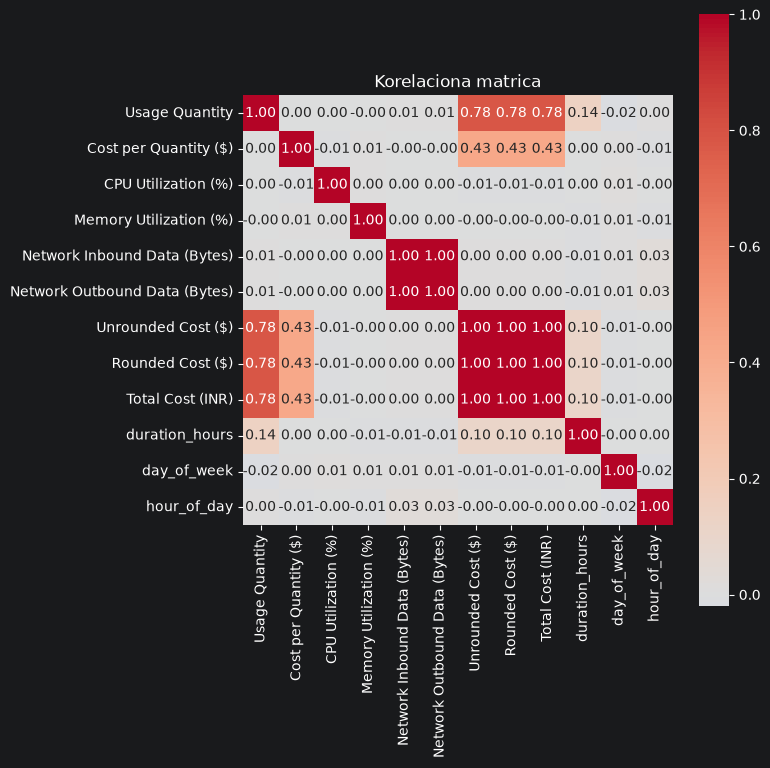

In [14]:
num_cols = ['Usage Quantity','Cost per Quantity ($)','CPU Utilization (%)','Memory Utilization (%)','Network Inbound Data (Bytes)','Network Outbound Data (Bytes)', 'Unrounded Cost ($)','Rounded Cost ($)', 'Total Cost (INR)', 'duration_hours','day_of_week','hour_of_day']
plot_correlation_heatmap(df,num_cols)

Na osnovu matrice korelacije, može se zaključiti da postoji visoka mulitkolinearnost izmedju promenljiva Unrounded Cost, Rounded Cost i Total Cost. Takodje se moze primetiti da postoji visoka korelacija izmedju ukupnog troska i količine potrošnje. Potrebno je izbaciti ovu promenljivu iz dataset-a. Takodje cemo izaciti promenljivu Cost per Quantity jer ima umerenu linearnu korelaciju sa izlaznom promenljivom

Promenljive troškova - Unrounded, Rounded, Total Cost, postoji visoka kolinearnost izmedju ovih promenljvi takoda smo odlučili da predviđamo jednu i izbacimo ostale promenljive. Koristićemo Unrounded Cost a izbaciti ostale

In [15]:
target = 'Unrounded Cost ($)'
df.drop(columns=['Rounded Cost ($)','Total Cost (INR)','Usage Quantity','Cost per Quantity ($)'],inplace=True)
df.head(5)

,Resource ID,CPU Utilization (%),Memory Utilization (%),Network Inbound Data (Bytes),Network Outbound Data (Bytes),Unrounded Cost ($),App Engine,Artifact Registry,BigQuery,Cloud Armor,...,asia-south1,europe-west1,us-central1,us-east1,us-west1,duration_hours,day_of_week,hour_of_day,Usage Start Date,Usage End Date
123312,resource_728,28.40,2.95,5.272183e+10,5.351907e+10,6946.68260,0,0,0,0,...,0,0,0,0,0,12.0,3,3,2023-12-21 03:00:00,2023-12-21 15:00:00
110175,resource_447,75.26,26.17,1.817140e+11,1.826700e+11,324.13590,0,0,0,0,...,0,0,1,0,0,132.0,2,18,2023-10-04 18:00:00,2023-10-10 06:00:00
23772,resource_78,62.15,70.30,3.516270e+11,3.524270e+11,89.68157,0,1,0,0,...,0,0,0,0,0,140.0,3,17,2022-05-19 17:00:00,2022-05-25 13:00:00
28436,resource_40,96.42,72.95,4.573060e+11,4.580290e+11,4385.45830,0,0,0,0,...,0,0,0,1,0,108.0,2,16,2022-06-15 16:00:00,2022-06-20 04:00:00
42086,resource_657,97.69,89.97,7.002910e+11,7.010510e+11,2126.70640,0,0,0,0,...,1,0,0,0,0,12.0,5,0,2022-09-03 00:00:00,2022-09-03 12:00:00


Testiranje asimetričnosti numeričkih kolona - asimetričnost raspodele može dovesti do faličnog treniranja modela i optimizacije backpropagation-om

In [16]:
num_cols = ['CPU Utilization (%)','Memory Utilization (%)','Network Inbound Data (Bytes)','Network Outbound Data (Bytes)', 'Unrounded Cost ($)' ,'duration_hours','day_of_week','hour_of_day']

In [17]:
import numpy as np
def plot_num_cols(df,columns,bins=40):
    n = len(columns)
    ncols = 3
    nrows = int(np.ceil(n/ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize= (6 * ncols, 6 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columns):
        data = df[col].dropna()
        label = col
        axes[i].hist(data, bins=bins,color='blue',edgecolor='black', alpha=0.8)
        axes[i].set_title(label)
        axes[i].set_xlabel(label)
        axes[i].set_ylabel("count")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

plt.tight_layout()
plt.show()



<Figure size 640x480 with 0 Axes>

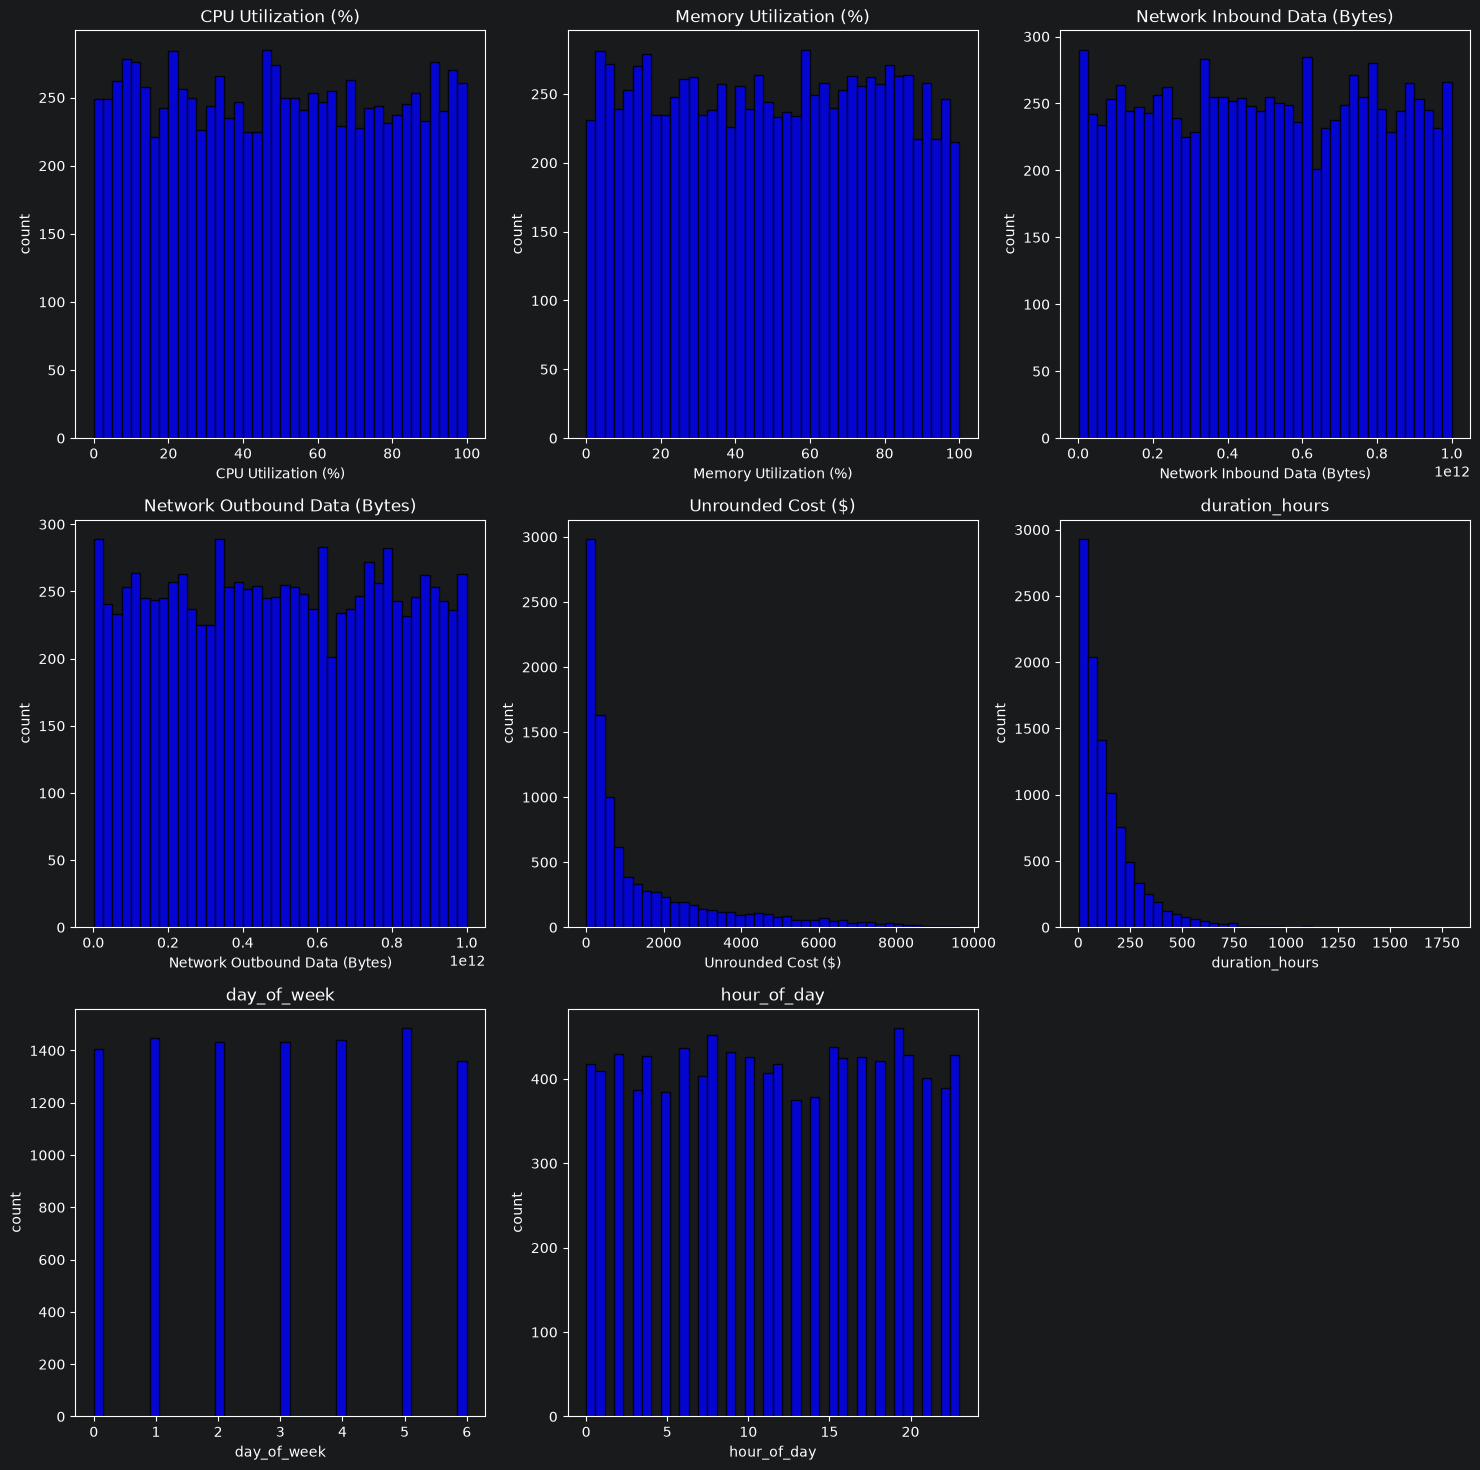

In [18]:
plot_num_cols(
    df,
    columns=num_cols)

Takodje cemo uraditi test asimetricnosti kako bismo imali dodatnu potvrdu o asimetricnosti

Na osnovu datih grafikona raspodela može se zaključiti da sve numeričke promenljive osim izlazne podležu uniformnoj raspodeli, nije potrebno raditi transformacije nad promenljivama. Što se tiče troškova njena raspodela je asimetrična udesno i potrebno ju je balansirati logaritamskom transformacijom. Biće nam takodje potvredno da je inverzno transformišemo kada tumačimo rezulate

In [19]:
from scipy.stats import skew
for col in num_cols:
    s = skew(df[col].dropna())
    print(f"{col}: skew = {s:.3f}")

CPU Utilization (%): skew = 0.017
Memory Utilization (%): skew = -0.005
Network Inbound Data (Bytes): skew = 0.001
Network Outbound Data (Bytes): skew = 0.001
Unrounded Cost ($): skew = 1.844
duration_hours: skew = 2.680
day_of_week: skew = -0.003
hour_of_day: skew = -0.006


In [20]:
col = "Unrounded Cost ($)"
print("Min vrednost:", df[col].min())
print("Broj negativnih:", (df[col] < 0).sum())
print("Broj NaN:", df[col].isna().sum())
print(df[col][df[col] < 0].head(10))

Min vrednost: 0.5823
Broj negativnih: 0
Broj NaN: 0
Series([], Name: Unrounded Cost ($), dtype: float64)


In [ ]:
negative_rows = df[df["Unrounded Cost ($)"] < 0]
print(negative_rows[["Resource ID", "Service Name", "Region / Zone",
                      "Unrounded Cost ($)", "duration_hours"]].head(10))

In [ ]:
df['Unrounded Cost ($)'] = np.log1p(df['Unrounded Cost ($)'])
df['duration_hours'] = np.log1p(df['duration_hours'])
df[['Unrounded Cost ($)','duration_hours']].head(5)

Nakon tranformacije, vršimo skaliranje svih numeričkih promenljivi kako bismo omogućili efektivnog gradijentnog spusta

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(df[num_cols])
df[num_cols] = scaler.transform(df[num_cols])

In [ ]:
df.head(5)

In [ ]:
df.info()